In [16]:
# from read_multi_ase_simple import *
from extract_simple import *
from simpleGNN import *

import sys 
import os 

import torch
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt

# from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool, Sequential, AttentionalAggregation
from torch_geometric.loader import DataLoader
from sklearn.model_selection import GridSearchCV, ParameterGrid
from tqdm import tqdm

## Section 0: Setting Up

Below, helper functions are defined for model training, validation, and testing. A helper function for plotting has also been defined, to help visualize the loss curves. 

In [6]:
def train_model(model, train_loader, val_loader, loss_fn, optimizer,        # code taken from Module 9 bloodmnist_pytroch.ipynb demo 
                epochs=10, print_every=1, device='cpu'):

    # for keeping track of total loss
    history = {'train_loss': [], 'val_loss': [],
               'train_mae': [], 'val_mae': [],
               'train_rmse': [], 'val_rmse': []}


    model = model.to(device) # move to device (cpu/gpu/mps as specified)

    for epoch in tqdm(range(epochs), desc='Training'):
        # TRAINING
        model.train()
        
        # initialize losses to 0 at start of each epoch 
        epoch_train_loss = 0.0
        epoch_train_mae = 0.0
        epoch_train_rmse = 0.0
        train_n = 0

        # iterate thru each batch 
        for batch in train_loader:
            batch = batch.to(device) # move to specified device 

            # inputs [x, edge_index, batch]
            predictions = model(batch.x, batch.edge_index, batch.batch)
            targets = batch.y.to(device) # reshape 

            # compare to target and calculate loss 
            loss = loss_fn(predictions, targets)

            optimizer.zero_grad() # zero out grads
            loss.backward() # back-prop 
            optimizer.step() # update/adjust 

            # calculate losses 
            epoch_train_loss += loss.item() # from optimizer 
            epoch_train_mae += torch.abs(predictions - targets).sum().item()
            epoch_train_rmse += ((predictions - targets) ** 2).sum().item()
            train_n += targets.numel()

        # calculate avg loss
        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_train_mae = epoch_train_mae / train_n
        avg_train_rmse = (epoch_train_rmse / train_n) ** 0.5

        # Validation
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_mae = 0.0
        epoch_val_rmse = 0.0
        val_n = 0

        with torch.no_grad():
            for val_batch in val_loader:
                val_batch = val_batch.to(device)

                val_predictions = model(val_batch.x, val_batch.edge_index, val_batch.batch).reshape(-1)
                val_targets = val_batch.y.reshape(-1).float().to(device)

                val_loss = loss_fn(val_predictions, val_targets)

                epoch_val_loss += val_loss.item()

                epoch_val_mae += torch.abs(val_predictions - val_targets).sum().item()
                epoch_val_rmse += ((val_predictions - val_targets) ** 2).sum().item()
                val_n += val_targets.numel()

        avg_val_loss = epoch_val_loss / len(val_loader)
        avg_val_mae = epoch_val_mae / val_n
        avg_val_rmse = (epoch_val_rmse / val_n) ** 0.5


        # Record
        history['train_loss'].append(avg_train_loss)
        history['train_mae'].append(avg_train_mae)
        history['train_rmse'].append(avg_train_rmse)

        history['val_loss'].append(avg_val_loss)
        history['val_mae'].append(avg_val_mae)
        history['val_rmse'].append(avg_val_rmse)
        
        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {avg_val_loss:.4f}"
            )

    return history

In [7]:
def test_model(model, test_loader, loss_fn, device='cpu'):
    history = {'test_loss': [], 'test_mae': [], 'test_rmse': []}

    model = model.to(device)
    model.eval()

    total_loss = 0.0
    total_mae = 0.0
    total_mse = 0.0
    n = 0

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)

            predictions = model(batch.x, batch.edge_index, batch.batch).reshape(-1)
            targets = batch.y.reshape(-1).float().to(device)

            loss = loss_fn(predictions, targets)

            total_loss += loss.item()
            total_mae += torch.abs(predictions - targets).sum().item()
            total_mse += ((predictions - targets) ** 2).sum().item()
            n += targets.numel()

    avg_loss = total_loss / len(test_loader)
    avg_mae = total_mae / n
    avg_rmse = (total_mse / n) ** 0.5

    history['test_loss'].append(avg_loss)
    history['test_mae'].append(avg_mae)
    history['test_rmse'].append(avg_rmse)

    print(
        f"Test Loss: {avg_loss:.4f} | "
        f"Test MAE: {avg_mae:.4f} | "
        f"Test RMSE: {avg_rmse:.4f}"
    )

    return history

In [8]:
def plot_train_val(history, model_name):
    """Plot training vs validation loss from a history dict."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].plot(history['train_mae'], label='Train', linewidth=2)
    ax[0].plot(history['val_mae'], label='Validation',
             linewidth=2, linestyle='--')
    ax[0].set_title(f'MAE')
    # ax[0].set_xlim(4)
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    ax[1].plot(history['train_rmse'], label='Train', linewidth=2)
    ax[1].plot(history['val_rmse'], label='Validation',
             linewidth=2, linestyle='--')
    ax[1].set_title(f'RMSE')
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    fig.suptitle(f"MAE and RMSE for {model_name}")

    plt.tight_layout()
    plt.show()

## Section 1: Loading the Dataset

In [9]:
my_path = '../../data'

# --------- EDIT THIS VALUE TO CHANGE EFFECTIVE DATASET SIZE -------------
max_mols = 500

files_list = find_files(my_path)

# Process files from list and extract specified number of molecules and type
dataset = process_file(files_list, molecule_type = 'biomolecules', max_molecules = max_mols)

# Get final dataset for use with PyG 
torch_data = get_data(dataset)

train_dataset, val_dataset, test_dataset = split_data(torch_data, 0.2, 0.2)
# train_dataset, val_dataset = split_data(torch_data, 0.2)

# print(len(train_dataset), len(val_dataset), len(test_dataset))
print(len(train_dataset), len(val_dataset), len(test_dataset))

Processed 500 atoms
320 80 100


In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

## Section 2: Variants of SimpleGNN

### Section 2.1: SimpleGNN 

SimpleGNN is a 3-layer Graph Convolutional Neural Network (GCN). It is our most "traditional" GNN. It serves as our baseline model. 

In [ ]:
class SimpleGNN(nn.Module):
    def __init__(self, num_node_features=1, hidden_channels=128):
        # call constructor from parent class 
        super().__init__()

        self.simpleGNN = Sequential('x, edge_index, batch', [
            # CONVOLUTION LAYERS: learn molecular represenation 
            # layer 1: directly bonded atoms
            (GCNConv(num_node_features, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 2: local chemical environment (i.e., funct groups)
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 3: adds global context
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),

            # POOLING: down-sample/reduce dimensions 
            (global_mean_pool, 'x, batch -> x'),

            # LINEAR LAYERS: turn into actual predictions 
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)])


    def forward(self, x, edge_index, batch):
        return self.simpleGNN(x, edge_index, batch)

In [ ]:
# hyperparameters 
param_grid = {
    'lr': [1e-5, 1e-4, 1e-3],
    'hidden_channels': [64, 128]}

grid = ParameterGrid(param_grid)

# other: 
# num convolutional layers = 3 -> per literature, this is the "sweet spot"

SimpleGNN(
  (simpleGNN): Sequential(
    (0) - GCNConv(1, 128): x, edge_index -> x
    (1) - ReLU(): x -> x
    (2) - GCNConv(128, 128): x, edge_index -> x
    (3) - ReLU(): x -> x
    (4) - GCNConv(128, 128): x, edge_index -> x
    (5) - ReLU(): x -> x
    (6) - <function global_mean_pool at 0x14a0685e0>: x, batch -> x
    (7) - Linear(in_features=128, out_features=128, bias=True): x -> x
    (8) - ReLU(): x -> x
    (9) - Linear(in_features=128, out_features=128, bias=True): x -> x
    (10) - ReLU(): x -> x
    (11) - Linear(in_features=128, out_features=1, bias=True): x -> x
  )
)

###  Section 2.2: SimpleGNN with Attention Pooling

Instead of aggregating node representations via global mean pooling, where all node features are averaged out (i.e., all equal importance), the below SimpleGNN variant, called AttentionGCN, applies attention pooling. This allows the model to learn importance of each node/atom based on its features. This should allow AttentionGCN to better learn realistic chemical relationships (i.e., functional groups), thereby improving model performance. 

In [22]:
# inherit from nn.Module 
class AttentionGCN(nn.Module):
    def __init__(self, num_node_features=1, hidden_channels=256):
        # call constructor from parent class 
        super().__init__()

        # define attention pooling -> map embedding/importance
        self.attention_pool = AttentionalAggregation(
            gate_nn=nn.Sequential(
                nn.Linear(hidden_channels, hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, 1)))

        self.attention = Sequential('x, edge_index, batch', [
            (GCNConv(num_node_features, 64), 'x, edge_index -> x'),
            nn.ReLU(),
            (GCNConv(64, 128), 'x, edge_index -> x'),
            nn.ReLU(),
            (GCNConv(128, 256), 'x, edge_index -> x'),
            nn.ReLU(),

            # POOLING: modified to attention pooling 
            (self.attention_pool, 'x, batch -> x'),

            # LINEAR LAYERS: turn into actual predictions 
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)])


    def forward(self, x, edge_index, batch):
        return self.attention(x, edge_index, batch).reshape(-1)

## SimpleGNN

In [9]:
# initialize model 
simpleGNN = SimpleGNN()

my_lr = 1e-3 # decreasing this val -> smoother loss curves 
my_loss_fn = nn.SmoothL1Loss()
my_optimizer = optim.Adam(simpleGNN.parameters(), lr=my_lr)

In [10]:
history = train_model(
    model = simpleGNN, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    loss_fn = my_loss_fn,
    optimizer = my_optimizer,
    epochs = 50,
    print_every = 5
)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:  10%|█         | 5/50 [00:02<00:25,  1.75it/s]

Epoch   5/50 | Train Loss: 1.4872 | Val Loss: 1.9449


Training:  20%|██        | 10/50 [00:05<00:21,  1.86it/s]

Epoch  10/50 | Train Loss: 1.4059 | Val Loss: 1.8166


...

Epoch  40/50 | Train Loss: 0.8517 | Val Loss: 0.9307


Training:  90%|█████████ | 45/50 [00:24<00:02,  1.91it/s]

Epoch  45/50 | Train Loss: 0.8929 | Val Loss: 1.1114


Training: 100%|██████████| 50/50 [00:26<00:00,  1.86it/s]

Epoch  50/50 | Train Loss: 0.8462 | Val Loss: 0.9118


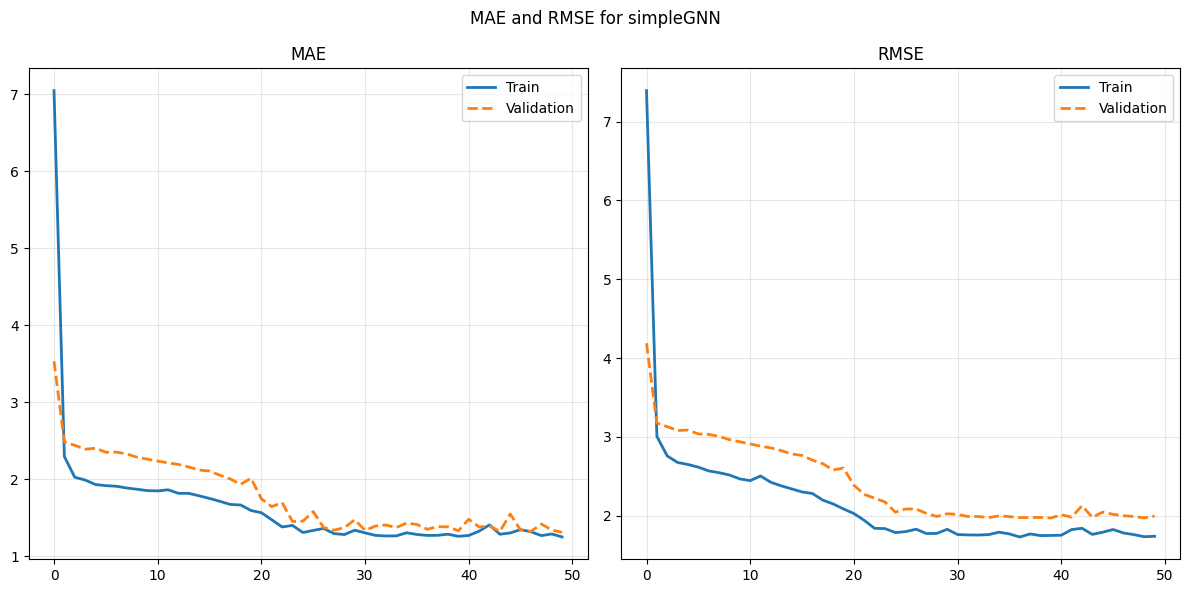

In [11]:
plot_train_val(history, 'simpleGNN')

In [12]:
print(f"Train: Final MAE = {history['train_mae'][-1]:.4f}")
print(f"Validation: Final MAE = {history['val_mae'][-1]:.4f}")

print(f"Train: Final RMSE = {history['train_rmse'][-1]:.4f}")
print(f"Validation: Final RMSE = {history['val_rmse'][-1]:.4f}")

Train: Final MAE = 1.2480
Validation: Final MAE = 1.3072
Train: Final RMSE = 1.7373
Validation: Final RMSE = 1.9935


In [13]:
test_history = test_model(
    model=simpleGNN,
    test_loader=test_loader,
    loss_fn=my_loss_fn,
    device='cpu'
)

print(test_history)

Test Loss: 0.7289 | Test MAE: 1.1285 | Test RMSE: 1.5544
{'test_loss': [0.728894123009273], 'test_mae': [1.1285088014602662], 'test_rmse': [1.5543624154667801]}


## SimpleGNN (with attention pooling)

In [24]:
# initialize model 
attentionGCN = AttentionGCN()

my_lr = 1e-3
my_loss_fn = nn.SmoothL1Loss()
my_optimizer = optim.Adam(attentionGCN.parameters(), lr=my_lr)

In [26]:
attn_history = train_model(
    model = attentionGCN, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    loss_fn = my_loss_fn,
    optimizer = my_optimizer,
    epochs = 100,
    print_every = 5
)

Training:   5%|▌         | 5/100 [00:03<01:05,  1.46it/s]

Epoch   5/100 | Train Loss: 1.7211 | Val Loss: 1.6066


Training:  10%|█         | 10/100 [00:06<01:01,  1.45it/s]

Epoch  10/100 | Train Loss: 1.6386 | Val Loss: 1.5206


Training:  15%|█▌        | 15/100 [00:10<00:57,  1.47it/s]

Epoch  15/100 | Train Loss: 1.3698 | Val Loss: 1.4010


Training:  18%|█▊        | 18/100 [00:12<00:56,  1.45it/s]


KeyboardInterrupt: 

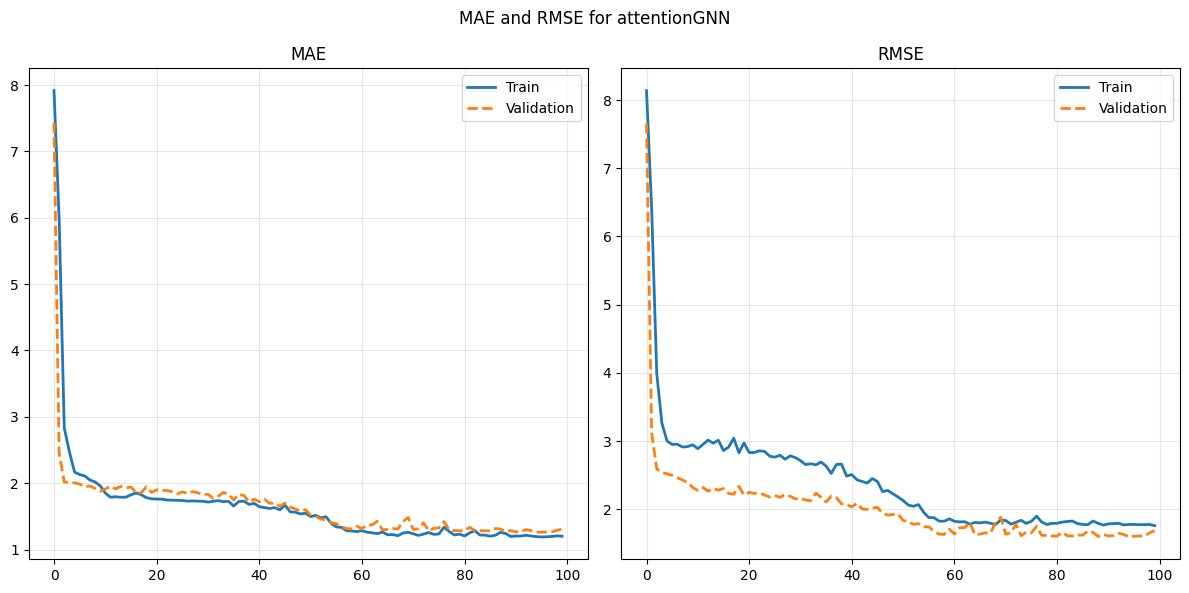

In [20]:
plot_train_val(attn_history, 'attentionGCN')

In [21]:
print(f"Train: Final MAE = {attn_history['train_mae'][-1]:.4f}")
print(f"Validation: Final MAE = {attn_history['val_mae'][-1]:.4f}")

print(f"Train: Final RMSE = {attn_history['train_rmse'][-1]:.4f}")
print(f"Validation: Final RMSE = {attn_history['val_rmse'][-1]:.4f}")

Train: Final MAE = 1.1998
Validation: Final MAE = 1.3076
Train: Final RMSE = 1.7596
Validation: Final RMSE = 1.6853


In [ ]:
attn_test_history = test_model(
    model=attentionGCN,
    test_loader=test_loader,
    loss_fn=my_loss_fn,
    device='cpu')

print(test_history)

Test Loss: 0.7036 | Test MAE: 1.0959 | Test RMSE: 1.5193
{'test_loss': [0.728894123009273], 'test_mae': [1.1285088014602662], 'test_rmse': [1.5543624154667801]}
